In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# -----------------------------------------------------------------
# SETUP (given — don't need to rewrite this on the exam, but know it)
# -----------------------------------------------------------------
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Class balance (train):\n{y_train.value_counts(normalize=True)}\n")

Train shape: (455, 30), Test shape: (114, 30)
Class balance (train):
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64



Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

[[38  4]
 [ 3 69]]


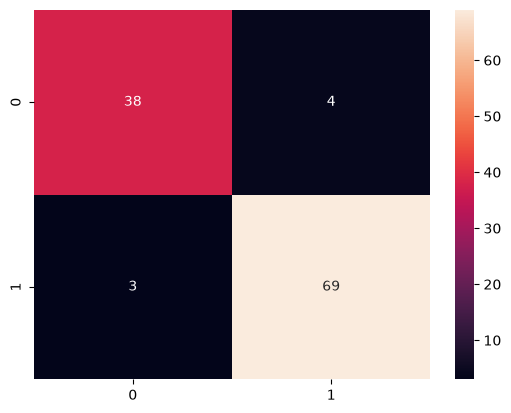

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()  #Naive Beyes model
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
score = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {score:.2f}")
print(classification_report(y_test, y_pred))
print(cm)

sns.heatmap(cm, annot=True)
plt.show()


In [ ]:
ss = StandardScaler() #Feature scaling
X_train_ss = ss.fit_transform(X_train) #why did we fit transform here?
X_test_ss = ss.transform(X_test)

best_acc= 0
best_k = 0
for k in [1,3,5,7,9,11,15]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_ss,y_train)
    y_pred = knn.predict(X_test_ss)
    score = accuracy_score(y_test,y_pred)
    if (score > best_acc):
        best_acc = score
        best_k = k
print(f"{best_k} gave the best accuracy of {best_acc}")

3 gave the best accuracy of 0.9824561403508771


In [25]:
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(criterion="gini", random_state=42)
dt1.fit(X_train,y_train)
y_pred1 = dt1.predict(X_test)
score1 = accuracy_score(y_test,y_pred1)
print(f"The accuracy for gini classifier is {score1}")

dt2 = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt2.fit(X_train,y_train)
y_pred2 = dt2.predict(X_test)
score2 = accuracy_score(y_test,y_pred2)
print(f"The accuracy for gini classifier is {score2}")

feat = pd.Series(dt1.feature_importances_, index=X.columns)
print(feat.sort_values(ascending=False).head(5))

tester = DecisionTreeClassifier(max_depth= 3)
tester.fit(X_train,y_train)
y_pred = tester.predict(X_test)
score = accuracy_score(y_pred,y_test)
print(score)

The accuracy for gini classifier is 0.9122807017543859
The accuracy for gini classifier is 0.9122807017543859
worst radius            0.697811
worst concave points    0.116083
worst texture           0.058881
texture error           0.052661
worst concavity         0.016325
dtype: float64
0.9385964912280702
